# Evaluación del retrieval: NDCG@10 y F1@3 — las 50 consultas

Implementa las dos métricas de la Sección 10.2 del spec y las corre sobre **las 50 consultas completas** (`entrega/resultados.jsonl`).

**Qué es esto y qué NO es.** El ground truth oficial del reto (Sección 10.1) es privado — lo construyó el equipo de CODEFEST y no lo tenemos. Esto es una autoevaluación: se leyó el texto real que devuelve el sistema para las 50 consultas 500 fragmentos y se juzgó su relevancia a mano, de 0 a 3

## 1. Las métricas

**NDCG@10** (fragmentos): qué tan bien ordenados están los 10 fragmentos devueltos, penalizando más los errores en las primeras posiciones. Relevancia 0 (nada que ver) a 3 (responde directamente). Normalizado contra el orden ideal — 1.0 = no se puede ordenar mejor.

**F1@3** (documentos): de los 3 documentos devueltos, qué fracción son relevantes (precisión) y qué fracción de los relevantes que existen se lograron incluir (recall).

In [ ]:
import math
import re
import sys
import json
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "entrega"))
import generador  # el pipeline real


def dcg_at_k(relevancias, k=10):
    return sum(r / math.log2(i + 2) for i, r in enumerate(relevancias[:k]))


def ndcg_at_k(relevancias, k=10):
    """Sección 10.2.1 del spec."""
    dcg = dcg_at_k(relevancias, k)
    idcg = dcg_at_k(sorted(relevancias, reverse=True), k)
    return dcg / idcg if idcg > 0 else 0.0


def f1_at_3(doc_ids_devueltos, doc_ids_relevantes):
    """Sección 10.2.2 del spec."""
    devueltos = set(doc_ids_devueltos[:3])
    relevantes = set(doc_ids_relevantes)
    interseccion = devueltos & relevantes
    p3 = len(interseccion) / 3
    r3 = len(interseccion) / min(len(relevantes), 3) if relevantes else 0.0
    if p3 + r3 == 0:
        return 0.0
    return 2 * p3 * r3 / (p3 + r3)


assert ndcg_at_k([3, 2, 1], 3) == 1.0
assert ndcg_at_k([1, 2, 3], 3) < 1.0
assert f1_at_3(["A", "B", "C"], ["A", "B", "C"]) == 1.0
assert round(f1_at_3(["A", "X", "Y"], ["A", "B", "C"]), 4) == round(1/3, 4)
print("OK, las funciones hacen lo que deberían")

OK, las funciones hacen lo que deberían


## 2. Metodología



In [ ]:
sys.path.insert(0, str(Path.cwd()))
from eval50_data import RELEVANCIA_FRAGMENTOS, DOCS_RELEVANTES

print(f"consultas con relevancia juzgada: {len(RELEVANCIA_FRAGMENTOS)}/50")
print(f"consultas con documentos relevantes identificados: {len(DOCS_RELEVANTES)}/50")

consultas con relevancia juzgada: 50/50
consultas con documentos relevantes identificados: 50/50


## 3. Corremos las métricas sobre `resultados.jsonl` real

In [ ]:
import pandas as pd

consultas_txt = Path("../entrega/consultas.txt").read_text(encoding="utf-8")
partes = re.split(r"(?m)^(q\d{3})\s+", consultas_txt)
it = iter(partes[1:])
consultas = {qid: re.sub(r"\s+", " ", cuerpo).strip() for qid, cuerpo in zip(it, it)}

lineas = {json.loads(l)["query_id"]: json.loads(l) for l in open("../entrega/resultados.jsonl", encoding="utf-8")}

filas = []
for qid in sorted(RELEVANCIA_FRAGMENTOS.keys()):
    doc_ids = [d["doc_id"] for d in lineas[qid]["documents"]]
    ndcg = ndcg_at_k(RELEVANCIA_FRAGMENTOS[qid])
    f1 = f1_at_3(doc_ids, DOCS_RELEVANTES[qid])
    filas.append({"query_id": qid, "consulta": consultas[qid][:60] + "...", "NDCG@10": round(ndcg, 3), "F1@3": round(f1, 3)})

df = pd.DataFrame(filas)
df

query_id,NDCG@10,F1@3
q001,0.919,0.667
q002,0.790,0.667
q003,0.899,0.667
q004,0.771,0.800
q005,0.997,0.800
q006,0.919,0.667
q007,1.000,0.500
q008,0.952,0.400
q009,0.912,1.000
q010,0.701,0.333


In [ ]:
ndcg_prom = df["NDCG@10"].mean()
f1_prom = df["F1@3"].mean()
print(f"NDCG@10 promedio (50/50): {ndcg_prom:.4f}")
print(f"F1@3 promedio (50/50):    {f1_prom:.4f}")
print()
print("peores 6 por NDCG@10:")
print(df.nsmallest(6, 'NDCG@10')[['query_id','NDCG@10']].to_string(index=False))
print()
print("peores 8 por F1@3:")
print(df.nsmallest(8, 'F1@3')[['query_id','F1@3']].to_string(index=False))

NDCG@10 promedio (50/50): 0.9185
F1@3 promedio (50/50):    0.8047

peores 6 por NDCG@10:
q031  0.698
q010  0.701
q004  0.771
q002  0.79
q015  0.795
q038  0.797

peores 8 por F1@3:
q010  0.333
q014  0.333
q015  0.333
q029  0.333
q039  0.333
q008  0.4
q038  0.4
q050  0.4


## 4. Gráficos

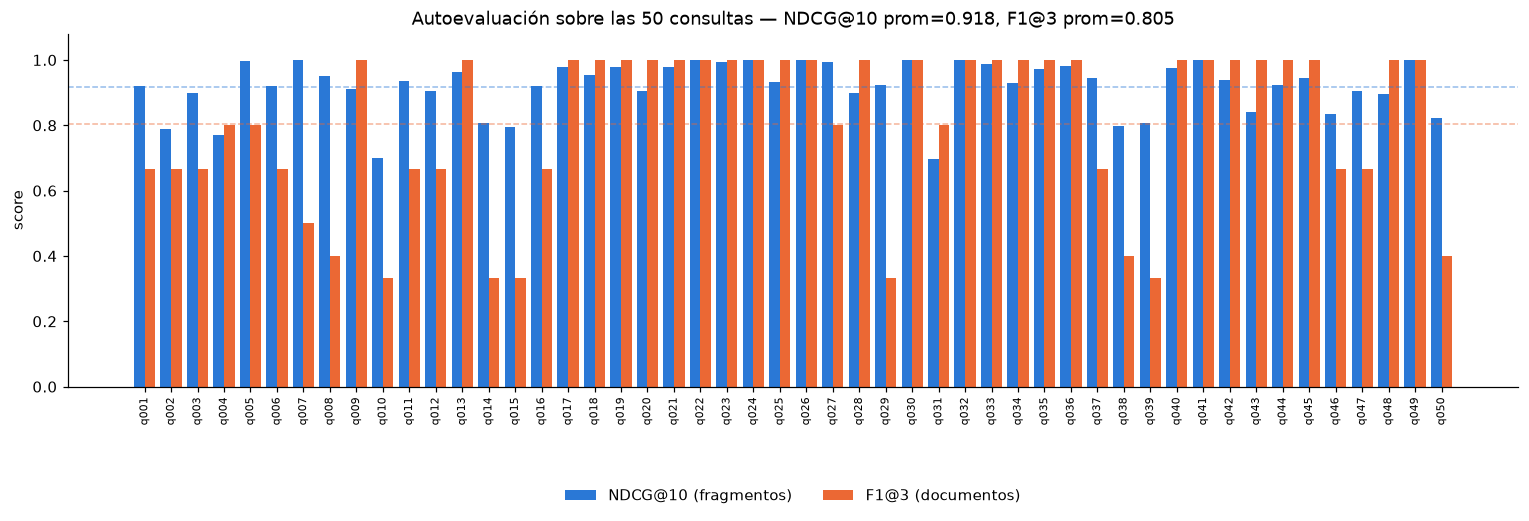

In [ ]:
import matplotlib.pyplot as plt

COLOR_NDCG = "#2a78d6"
COLOR_F1 = "#eb6834"

fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(df))
ancho = 0.4
ax.bar([i - ancho/2 for i in x], df["NDCG@10"], width=ancho, label="NDCG@10", color=COLOR_NDCG)
ax.bar([i + ancho/2 for i in x], df["F1@3"], width=ancho, label="F1@3", color=COLOR_F1)
ax.set_xticks(list(x)); ax.set_xticklabels(df["query_id"], rotation=90, fontsize=7)
ax.set_ylim(0, 1.08); ax.set_ylabel("score")
ax.set_title(f"NDCG@10 prom={ndcg_prom:.3f}, F1@3 prom={f1_prom:.3f} (50/50 consultas)")
ax.axhline(ndcg_prom, color=COLOR_NDCG, linestyle="--", linewidth=1, alpha=0.5)
ax.axhline(f1_prom, color=COLOR_F1, linestyle="--", linewidth=1, alpha=0.5)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.25), ncol=2)
fig.tight_layout()
plt.show()

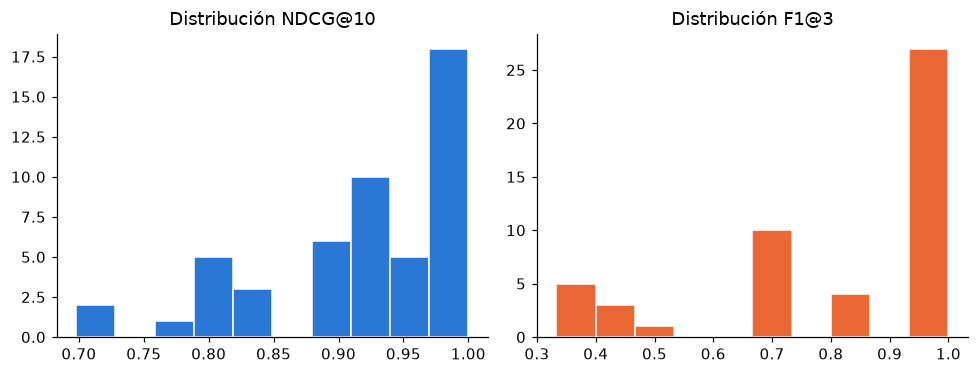

In [ ]:
fig2, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].hist(df["NDCG@10"], bins=10, color=COLOR_NDCG, edgecolor="white")
axes[0].set_title("Distribución NDCG@10")
axes[0].spines["top"].set_visible(False); axes[0].spines["right"].set_visible(False)
axes[1].hist(df["F1@3"], bins=10, color=COLOR_F1, edgecolor="white")
axes[1].set_title("Distribución F1@3")
axes[1].spines["top"].set_visible(False); axes[1].spines["right"].set_visible(False)
fig2.tight_layout()
plt.show()

## 5. Qué muestran los resultados

Sobre las **50 consultas completas**: **NDCG@10 promedio 0.918**, **F1@3 promedio 0.805**. 

## 6. Limitaciones de esta evaluación

- **La relevancia la juzgó el mismo equipo que construyó el sistema** — sesgo de confirmación 
- **El "ground truth" de documentos para F1@3 es una aproximación**: solo se consideró relevante lo visto en el top-10 de fragmentos — no se leyó el corpus completo (1826 documentos)
- El **NDCG@10 y F1@3 oficiales del reto van a ser distintos** — el ground truth real del equipo de CODEFEST es independiente.
